In [1]:
import os
#import deeptile
import matplotlib.pyplot as plt
import numpy as np
# from deeptile.extensions import stitch
import tifffile
import dask.array as da
import utils
import skimage as ski
from find_neighbors import objects_bounds
# import extract_features
import pandas as pd
#from collections import defaultdict
# from extract_features import features_basic, foci_features, feature_table, neighbor_measurements
#from scipy import ndimage as ndi
import time
import extract_features
import ast
from brieflow_segment_utils import image_log_scale
from scipy import ndimage as ndi
import timeit
from dask.distributed import Client
from utils import foci_per_region
from functools import reduce
import operator
from skimage.measure._regionprops import _props_to_dict as props_to_dict
from skimage.measure import regionprops_table
# from microfilm.microplot import microshow

In [18]:
import importlib
importlib.reload(utils)
from utils import foci_per_region
importlib.reload(extract_features)
from extract_features import feature_table_per_region, neighbor_measurements,foci_count,foci_area
import find_neighbors
importlib.reload(find_neighbors)
from find_neighbors import objects_bounds

In [ ]:
nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_nuclei_mask.tif"
foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_foci.tif"
cyto_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day24_s12_cytoplasm_mask.tif"
cy5_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_cy5.ome.tif"
gfp_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12_gfp.ome.tif"
coverslip_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_coverslip.tif"
results_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12.csv"

cy5 = tifffile.memmap(cy5_path, mode='r')
gfp = tifffile.memmap(gfp_path, mode='r')
nuclei = tifffile.memmap(nuclei_mask_path, mode='r')
cells = tifffile.memmap(cyto_mask_path, mode='r')
# foci = tifffile.memmap(foci_mask_path, mode='r')

In [16]:
day18_img_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day18.ome.tif"
day18_coverslip_path = "/Users/hannahbolen/Desktop/image_analysis/o8p_day18_coverslip.ome.tiff"

day18_nuclei_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day18_nuclei_mask.tif"
day18_cyto_mask_path = "/Users/hannahbolen/Desktop/image_analysis/here/o8p_day18_cytoplasm_mask.tif"

day18_gfp_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day18_gfp.tif"
day18_cy5_path = "/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day18_cy5.tif"

# img_dtype = tifffile.TiffFile(img_path).pages[0].dtype

# coverslip = da.from_array(tifffile.imread(coverslip_path))
day18_cy5 = tifffile.memmap(day18_cy5_path, mode='r')
day18_nuclei = tifffile.memmap(day18_nuclei_mask_path, mode='r')
day18_gfp = tifffile.memmap(day18_gfp_path, mode='r')
day18_cyto = tifffile.memmap(day18_cyto_mask_path, mode='r')

In [19]:
features_basic = ["label","bbox","centroid","area","intensity_mean","intensity_max","intensity_min","intensity_std","eccentricity"]
foci_features = ["label", "foci_count", "foci_area"]
foci_extraprops = (foci_count,foci_area,)

In [ ]:
results.to_csv("/Users/hannahbolen/Desktop/image_analysis/slide_tiff/o8p_day24_s12.csv")

In [11]:
distance = 30
minimums_i, maximums_i, minimums_j, maximums_j = objects_bounds(day18_nuclei, distance)
nobjects = np.max(day18_nuclei)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1
kwargs = {"radius":3, "sigma":2,"threshold":15, "min_distance":1, "remove_border_foci":True}

In [12]:
# kwargs_scatter = client.scatter(kwargs)
# minimums_i, maximums_i, minimums_j, maximums_j = objects_bounds(nuclei, distance)

client = Client()
try:
    futures = client.map(
        foci_per_region,
        object_indexes.tolist(),
        minimums_i.tolist(),
        maximums_i.tolist(),
        minimums_j.tolist(),
        maximums_j.tolist(),
        [day18_cy5_path] * len(object_indexes),
        [day18_nuclei_mask_path] * len(object_indexes),
        **kwargs,
    )

    result = client.gather(futures)
    client.close()
except:
    client.close()


combined = reduce(operator.or_, result, {})

In [13]:
foci = np.zeros_like(day18_nuclei)
offset = 0
for key, val in combined.items():
    if val is None or val.size == 0:
        continue

    m = val > 0
    if not np.any(m):
        continue
    
    out = val.copy()
    out[m] += offset

    foci_patch = foci[
        minimums_i[key-1] : maximums_i[key-1],
        minimums_j[key-1] : maximums_j[key-1]
    ]
    foci_patch[m] = out[m]

    offset = out.max()

In [ ]:
dfs = []
dfs.append(
    pd.DataFrame(regionprops_table(day18_nuclei, gfp, features_basic, separator=""))
    .set_index("label")
    .rename(columns={"centroid0":"i","centroid1":"j"})
    .add_prefix("nucleus_")
)
dfs[0]["nucleus_bbox"]=dfs[0][["nucleus_bbox0","nucleus_bbox1","nucleus_bbox2",'nucleus_bbox3']].apply(tuple, axis=1)
dfs[0]=dfs[0].drop(columns=["nucleus_bbox0","nucleus_bbox1","nucleus_bbox2",'nucleus_bbox3'])
dfs.append(
    pd.DataFrame(regionprops_table(cells, cy5, features_basic, separator=""))
    .set_index("label")
    .rename(columns={"centroid0":"i","centroid1":"j"})
    .add_prefix("cells_")
)
dfs[1]["cells_bbox"]=dfs[1][["cells_bbox0","cells_bbox1","cells_bbox2",'cells_bbox3']].apply(tuple, axis=1)
dfs[1]=dfs[1].drop(columns=["cells_bbox0","cells_bbox1","cells_bbox2",'cells_bbox3'])
dfs.append(
    pd.DataFrame(regionprops_table(nuclei, foci, foci_features, separator="", extra_properties=foci_extraprops))
    .set_index("label")
)

results = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)

In [7]:
minimums_i500, maximums_i500, minimums_j500, maximums_j500 = objects_bounds(day18_nuclei, 750)

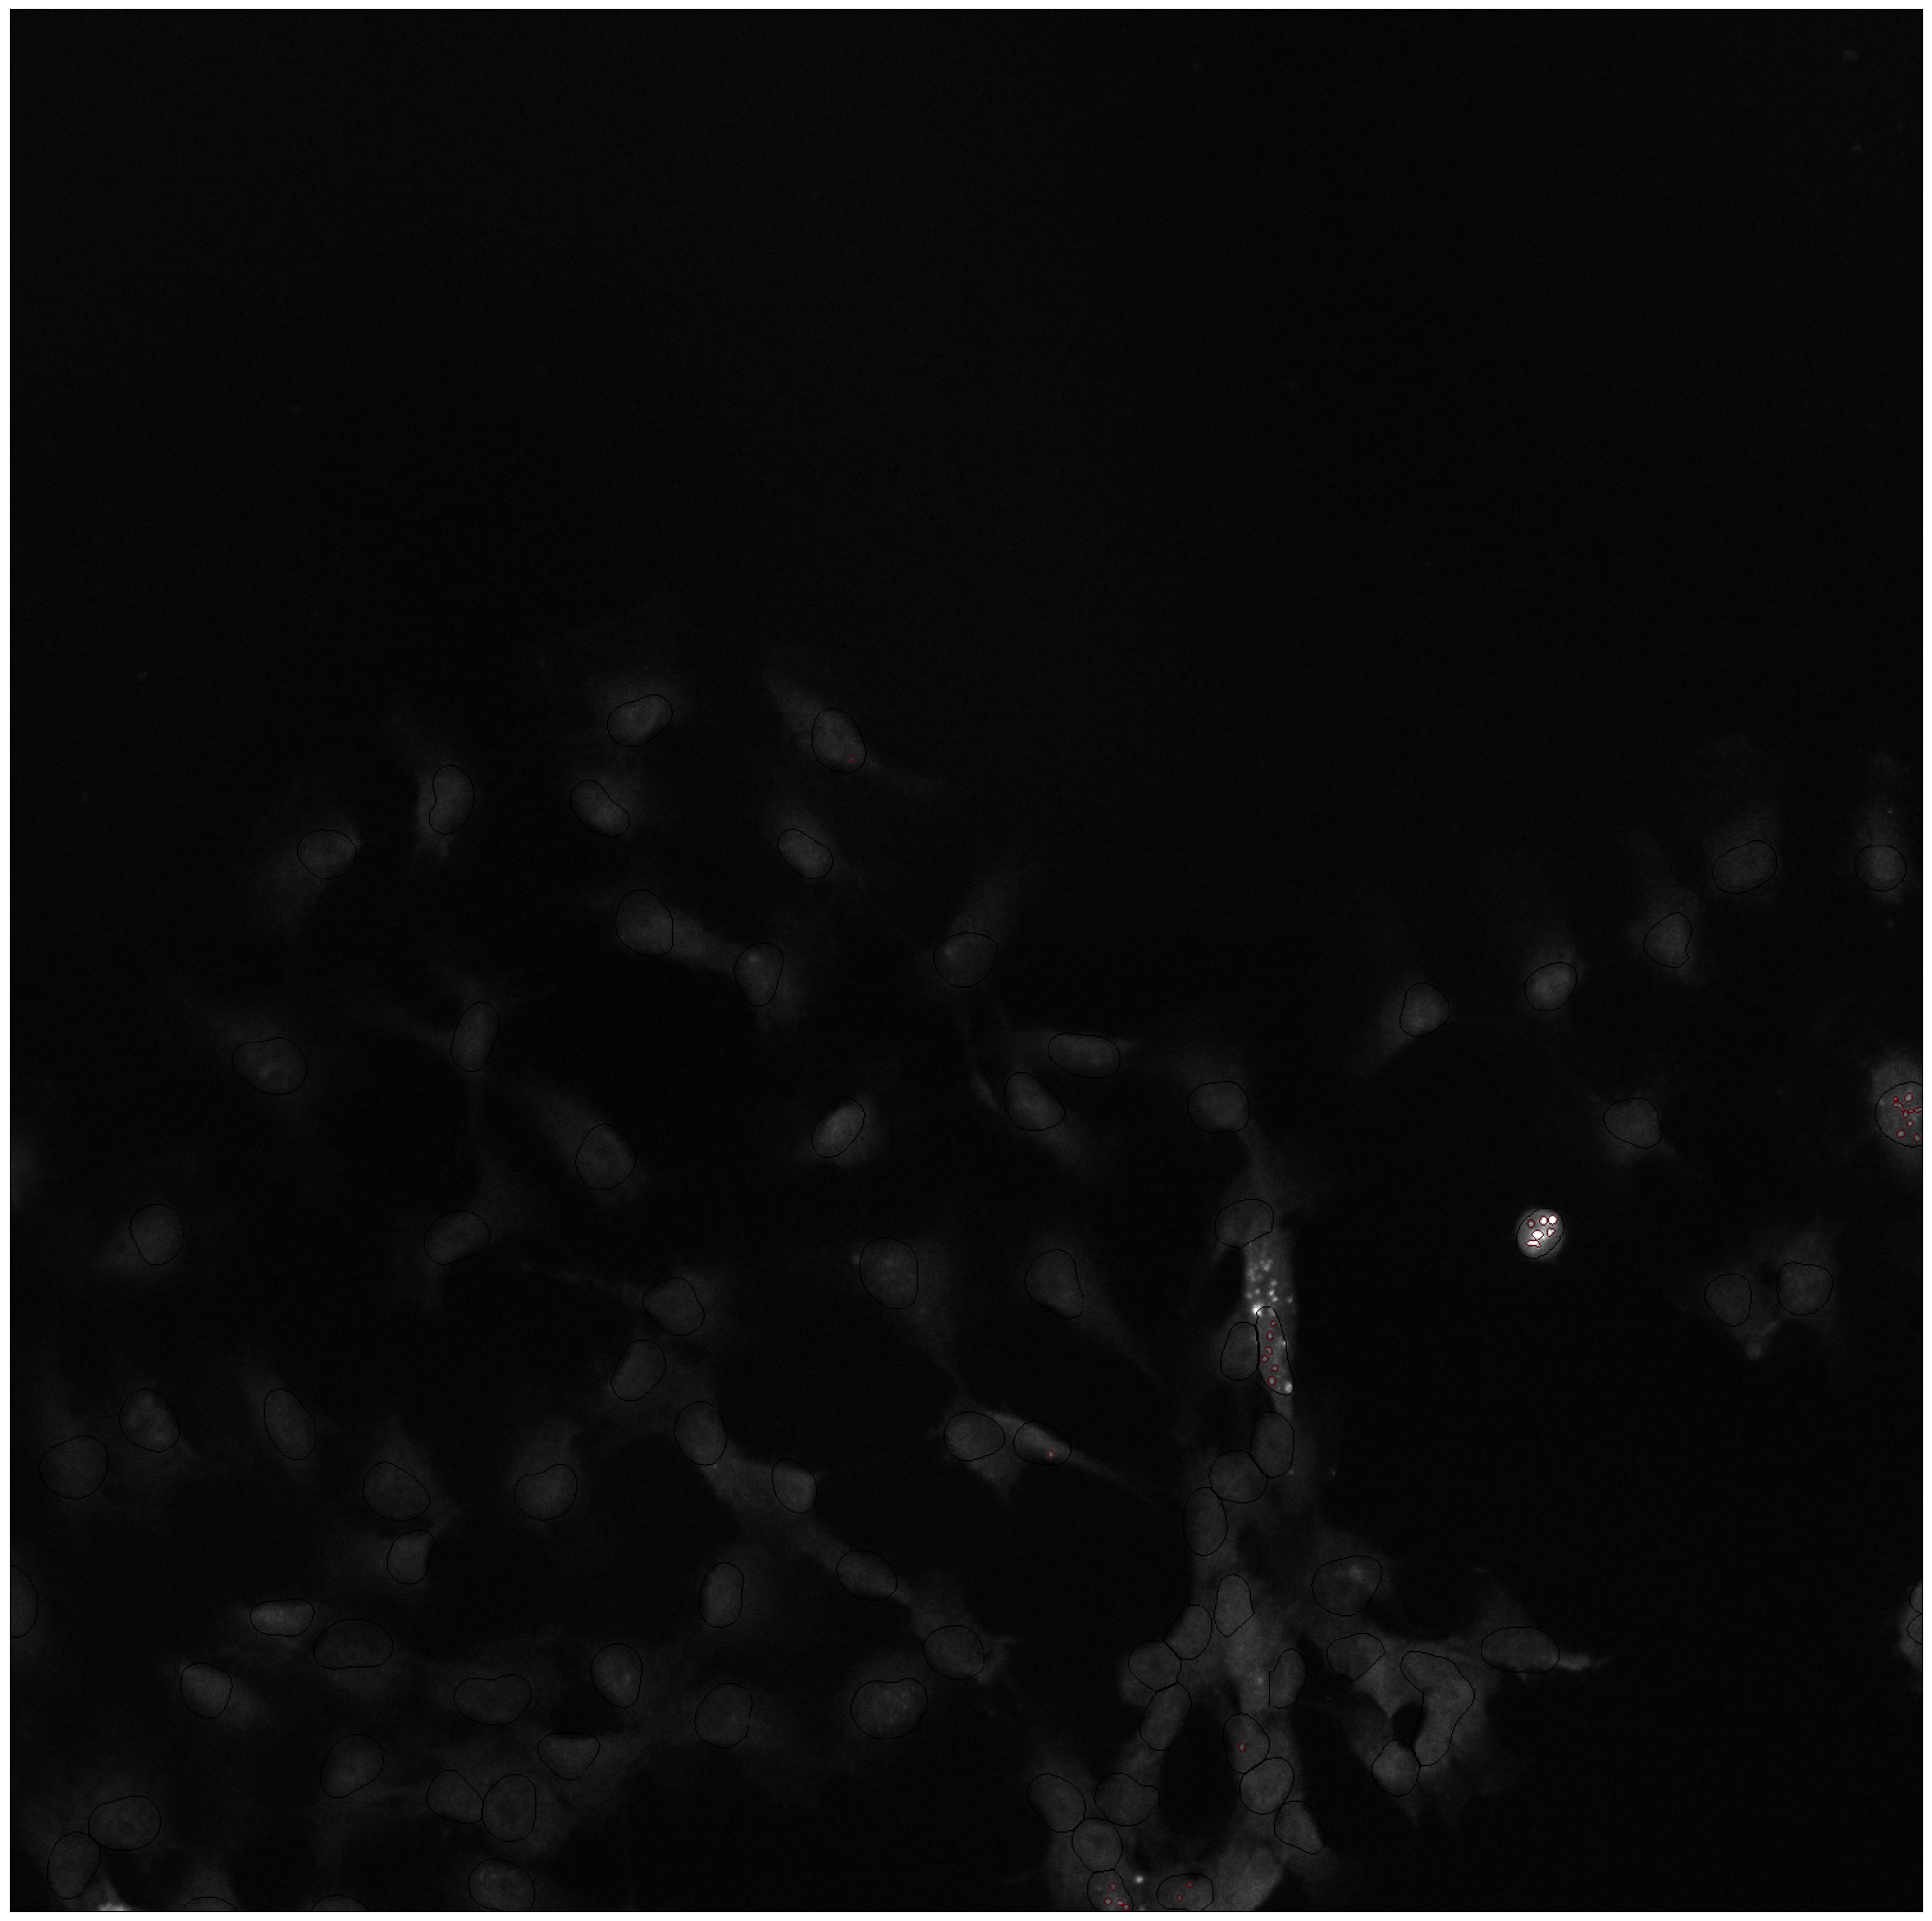

In [15]:
k = 213
patch_cy5 = day18_cy5[
    minimums_i500[k] : maximums_i500[k],
    minimums_j500[k] : maximums_j500[k],
]

# patch_gfp = gfp[
#     minimums_i500[k] : maximums_i500[k],
#     minimums_j500[k] : maximums_j500[k],
# ]

patch_nuclei = day18_nuclei[
    minimums_i500[k] : maximums_i500[k],
    minimums_j500[k] : maximums_j500[k],
]

patch_foci = foci[
    minimums_i500[k] : maximums_i500[k],
    minimums_j500[k] : maximums_j500[k],
]

patch_mask = patch_nuclei == k+1
# patch_img_masked = np.where(patch_mask, patch_img, 0)
# patch_img_masked = patch_img*(patch_nuclei>0)

# composite = np.stack((patch_gfp, patch_cy5), axis=0)
# plt.subplots(figsize=(20,20))


nuc_outline = ski.segmentation.find_boundaries(patch_nuclei,mode="outer")
nuc_outline = np.ma.masked_where(nuc_outline==False,nuc_outline)

foci_outline = ski.segmentation.find_boundaries(patch_foci,mode="outer")
foci_outline = np.ma.masked_where(foci_outline==False,foci_outline)

fig,ax = plt.subplots(figsize=(20,20))
ax.imshow(ski.exposure.rescale_intensity(patch_cy5, in_range=(0,3000)),cmap="gray")
#show = microshow(images=composite, cmaps=['pure_green','pure_magenta'], limits=[[0,4000],[0,3500]], ax=ax)
ax.imshow(nuc_outline, cmap="Grays_r")
ax.imshow(foci_outline,cmap="Reds_r")
ax.set_yticks([])
ax.set_xticks([])
plt.tight_layout()

In [ ]:
from utils import log_ndi

In [ ]:
kwargs = {"radius":3, "sigma":2,"threshold":ski.filters.threshold_yen, "min_distance":1, "remove_border_foci":True}

In [ ]:
k = 4300
patch_cy5 = cy5[
    minimums_i500[k] : maximums_i500[k],
    minimums_j500[k] : maximums_j500[k],
]
patch_nuclei = nuclei[
    minimums_i500[k] : maximums_i500[k],
    minimums_j500[k] : maximums_j500[k],
]
nuc_outline = ski.segmentation.find_boundaries(patch_nuclei,mode="outer")
nuc_outline = np.ma.masked_where(nuc_outline==False,nuc_outline)

tophat = ski.morphology.white_tophat(
    patch_cy5, footprint=ski.morphology.disk(3)
)
tophat_log = log_ndi(tophat, sigma=2)

In [ ]:
tophat_log.max()

In [ ]:
fig,ax = plt.subplots(figsize=(20,20))
ax.imshow(ski.exposure.rescale_intensity(tophat_log, in_range=(0,50)),cmap="gray")
#show = microshow(images=composite, cmaps=['pure_green','pure_magenta'], limits=[[0,4000],[0,3500]], ax=ax)
# ax.imshow(nuc_outline, cmap="Grays_r")
# ax.imshow(foci_outline,cmap="Reds_r")
ax.set_yticks([])
ax.set_xticks([])
plt.tight_layout()

In [ ]:
# foci_mask_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/temp/o8p_day24_s12_foci.tif"
tifffile.imwrite(foci_mask_path, foci, dtype=foci.dtype)

In [ ]:
distance = 100
min_i_nuclei, max_i_nuclei, min_j_nuclei, max_j_nuclei = objects_bounds(nuclei, distance)
min_i_cells, max_i_cells, min_j_cells, max_j_cells = objects_bounds(cells, distance)
nobjects = np.max(nuclei)
object_indexes = np.arange(nobjects, dtype=np.int32) + 1

In [ ]:
client = Client()

In [ ]:
client.restart()

In [ ]:
# client.restart()
dfs = []
futures_nuclei = client.map(
    feature_table_per_region,
    object_indexes.tolist(),
    min_i_nuclei.tolist(),
    max_i_nuclei.tolist(),
    min_j_nuclei.tolist(),
    max_j_nuclei.tolist(),
    [nuclei_mask_path] * len(object_indexes),
    [features_basic] * len(object_indexes),
    [gfp_path] * len(object_indexes),
)

futures_cells = client.map(
    feature_table_per_region,
    object_indexes.tolist(),
    min_i_cells.tolist(),
    max_i_cells.tolist(),
    min_j_cells.tolist(),
    max_j_cells.tolist(),
    [cyto_mask_path] * len(object_indexes),
    [features_basic] * len(object_indexes),
    [cy5_path] * len(object_indexes),
)

futures_foci = client.map(
    feature_table_per_region,
    object_indexes.tolist(),
    min_i_nuclei.tolist(),
    max_i_nuclei.tolist(),
    min_j_nuclei.tolist(),
    max_j_nuclei.tolist(),
    [nuclei_mask_path] * len(object_indexes),
    [foci_features] * len(object_indexes),
    [foci_mask_path] * len(object_indexes),
)

results_nuclei = client.gather(futures_nuclei)
results_cells = client.gather(futures_cells)
results_foci = client.gather(futures_foci)
client.close()


dfs.append(pd.concat(results_nuclei).set_index("label").add_prefix("nucleus_"))
dfs.append(pd.concat(results_cells).set_index("label").add_prefix("cells_"))
dfs.append(pd.concat(results_foci).set_index("label"))

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)


In [ ]:
bounds = np.array([min_i_nuclei, max_i_nuclei, min_j_nuclei, max_j_nuclei])

In [ ]:
results_fullslide = pd.concat(dfs,axis=1,join="outer",ignore_index=True)

In [ ]:
results_nuclei[4216]

In [ ]:
results_nuclei[4215]

In [ ]:
labels = tifffile.memmap(nuclei_mask_path)
labels = labels[
    min_i_nuclei[4215] : max_i_nuclei[4215],
    min_j_nuclei[4215] : max_j_nuclei[4215],
]
np.unique(labels)

In [ ]:
labels[labels != 4215+1] = 0
np.unique(labels)

In [ ]:
dfs = []
dfs.append(
    feature_table(nucleus, features_basic, img[0])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    feature_table(cells, features_basic, img[1])
    .set_index("label")
    .add_prefix("cells_")
)

dfs.append(
    feature_table(nucleus, foci_features, foci)
    .set_index("label")
)

dfs.append(
    neighbor_measurements(nucleus, distances=[1])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    neighbor_measurements(cells, distances=[1])
    .set_index("label")
    .add_prefix("cells_")
)

finish_feature_extract = time.time()

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)

In [ ]:
from extract_features import feature_table
add_props = {"label": lambda r: r.label,
            "intensity_min": lambda r: r.intensity_min,
             "intensity_std": lambda r: r.intensity_std,
             "eccentricity": lambda r: r.eccentricity
}
start_feature_extract = time.time()

dfs = []
dfs.append(
    feature_table(masks[0], add_props, img[0])
    .set_index("label")
    .add_prefix("nucleus_")
)

dfs.append(
    results_fullslide
)

finish_feature_extract = time.time()

results_path = "/Users/hannahbolen/Desktop/image_analysis/masks_and_results/o8p_day24_s12_filtered2.csv"

results_fullslide = pd.concat(dfs, axis=1, join="outer", sort=False).reset_index().set_index("label", drop=True)
results_fullslide.to_csv(results_path)
print(finish_feature_extract-start_feature_extract)
